Goal:
To learn the structure of a Bayesian Network from observed data using the Peter–Clark (PC) algorithm, and to compare how the choice of Conditional Independence (CI) tests—Pearson correlation for continuous variables and Chi-square for categorical variables—affects the resulting network. 

**Install Libraries**

In [1]:
# Install required libraries
!pip install pandas numpy scipy pgmpy

In [2]:
# ---------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import skew, kurtosis, trim_mean
from statsmodels.robust.scale import mad as sm_mad
from scipy.stats import pearsonr
from pgmpy.estimators import PC
#from pgmpy.models import BayesianModel

**1. Load AMIB data**

In [3]:
# ---------------------------------------------------------------
# Load AMIB daily data
# ---------------------------------------------------------------

df = pd.read_csv("AMIB_daily.csv")
print(df.head())


    id  day  slphrs  slpwell  weath  lteq   pss   se  ssgs_shame  ssgs_guilt  \
0  101    0     6.0      1.0    1.0  10.0  2.50  2.0         1.4         2.2   
1  101    1     2.0      1.0    2.0  10.0  2.75  3.0         1.4         1.4   
2  101    2     9.0      3.0    3.0  10.0  3.50  4.0         1.0         1.0   
3  101    3     7.5      3.0    2.0   9.0  3.00  4.0         1.0         1.0   
4  101    4     8.0      4.0    1.0  18.0  2.75  3.0         1.0         1.0   

   ...  pfi_hubr  evalday  posaff  negaff  affbalance  temp   hum  wind  \
0  ...  2.000000      1.0     3.9     3.0         0.9  28.0  0.79  11.0   
1  ...  1.142857      0.0     3.8     2.3         1.5  20.8  0.62   3.6   
2  ...  1.000000      1.0     5.1     1.0         4.1  29.1  0.51   1.9   
3  ...  1.000000      1.0     5.6     1.3         4.3  30.2  0.58   2.7   
4  ...  1.000000      1.0     4.3     1.1         3.2  22.7  0.55   2.4   

     bar  prec  
0  29.40  0.20  
1  30.17  0.00  
2  30.35  0.02  


**2. Describe the variables of interest in the AMIB data**

In [4]:
# ---------------------------------------------------------------
# 2(a) Select positive affect variables
# ---------------------------------------------------------------

var_pos = [
    "enthusiastic", "calm", "happy", "peaceful", "satisfied",
    "proud", "relaxed", "excited", "content", "relieved"
]
pos_affect_data = df[var_pos].copy()

# ---------------------------------------------------------------
# 2(b) Statistics Summary
# ---------------------------------------------------------------

def describe_series(s: pd.Series, trim=0.10):
    x = s.dropna().astype(float).values
    n = x.size
    if n == 0:
        return pd.Series({
            "n": np.nan, "mean": np.nan, "sd": np.nan, "median": np.nan,
            "trimmed": np.nan, "mad": np.nan, "min": np.nan, "max": np.nan,
            "range": np.nan, "skew": np.nan, "kurtosis": np.nan, "se": np.nan
        })

    mean_ = np.mean(x)
    sd_ = np.std(x, ddof=1)
    median_ = np.median(x)
    trimmed_ = trim_mean(x, proportiontocut=trim)
    mad_ = sm_mad(x)
    min_ = np.min(x)
    max_ = np.max(x)
    rng_ = max_ - min_
    skew_ = skew(x, bias=False)
    kurt_ = kurtosis(x, fisher=True, bias=False)
    se_ = sd_ / np.sqrt(n)

    return pd.Series({
        "n": n,
        "mean": round(mean_, 2),
        "sd": round(sd_, 2),
        "median": round(median_, 2),
        "trimmed": round(trimmed_, 2),
        "mad": round(mad_, 2),
        "min": round(min_, 0),
        "max": round(max_, 0),
        "range": round(rng_, 0),
        "skew": round(skew_, 2),
        "kurtosis": round(kurt_, 2),
        "se": round(se_, 2)
    })

# --- Apply to all variables ---
desc = pos_affect_data.apply(describe_series).T

# Add variable names instead of numbers
desc.insert(0, "vars", desc.index)

# Reorder columns to mirror R's psych::describe layout
desc = desc[[
    "vars", "n", "mean", "sd", "median", "trimmed", "mad",
    "min", "max", "range", "skew", "kurtosis", "se"
]]

# --- Display the final descriptive statistics table ---
print(desc.to_string(index=False))


        vars      n  mean   sd  median  trimmed  mad  min  max  range  skew  kurtosis   se
enthusiastic 1441.0  4.21 1.56     4.0     4.24 1.48  1.0  7.0    6.0 -0.20     -0.61 0.04
        calm 1441.0  4.40 1.46     4.0     4.46 1.48  1.0  7.0    6.0 -0.25     -0.45 0.04
       happy 1441.0  4.67 1.35     5.0     4.72 1.48  1.0  7.0    6.0 -0.35     -0.24 0.04
    peaceful 1441.0  4.26 1.52     4.0     4.30 1.48  1.0  7.0    6.0 -0.21     -0.59 0.04
   satisfied 1438.0  4.34 1.47     4.0     4.39 1.48  1.0  7.0    6.0 -0.23     -0.45 0.04
       proud 1440.0  3.41 1.65     3.5     3.34 2.22  1.0  7.0    6.0  0.15     -0.83 0.04
     relaxed 1439.0  4.01 1.56     4.0     4.04 1.48  1.0  7.0    6.0 -0.13     -0.61 0.04
     excited 1439.0  3.84 1.67     4.0     3.84 1.48  1.0  7.0    6.0  0.04     -0.85 0.04
     content 1441.0  4.42 1.53     4.0     4.46 1.48  1.0  7.0    6.0 -0.25     -0.58 0.04
    relieved 1439.0  3.04 1.62     3.0     2.92 1.48  1.0  7.0    6.0  0.44     -0.59 0.04

**3. Learn Network**

not sure if we needed to make any observations or anything but just incase:

chi_sqaure and g_sq feels way less connected in general, most likely because they are more tight-knit in terms of what they grab and show

pearsonr and gcm give out a ton of connections and have similar results but with a slightly different shape, both had happy become their most connected node while chi_square gave only two.



In [26]:
# ---------------------------------------------------------------
# STEP 3 — Learn the Bayesian network with PC (Stable, Pearson)
# ---------------------------------------------------------------
import numpy as np
from pgmpy.estimators import PC

# 3.1 Ensure numeric & make a listwise-complete frame for PC
data_num = pos_affect_data.apply(pd.to_numeric, errors="coerce")
pc_input = data_num.dropna(axis=0, how="any").copy()

# 3.2 Learn structure: PC (Stable) + Pearson correlation CI test
pc = PC(pc_input)
dag = pc.estimate(
    variant="stable",
    ci_test="g_sq",      #Insert ['chi_square', 'g_sq', 'log_likelihood', 'modified_log_likelihood', 'pearsonr', 'pillai', 'gcm', 'power_divergence', 'independence_match']
    significance_level= 0.05,   #Insert [0.05, 0.10 , 0.20]
    return_type="dag"
)


# 3.3 bnlearn-like summary
nodes = list(dag.nodes())
edges = list(dag.edges())

# neighbourhood sizes
neighbors = {n: set(dag.predecessors(n)) | set(dag.successors(n)) for n in nodes}

# markov blanket sizes (parents ∪ children ∪ co-parents of children)
mb_sizes = []
for n in nodes:
    parents = set(dag.predecessors(n))
    children = set(dag.successors(n))
    spouses = set().union(*[set(dag.predecessors(c)) for c in children]) if children else set()
    mb = (parents | children | spouses) - {n}
    mb_sizes.append(len(mb))

avg_mb = float(np.mean(mb_sizes)) if mb_sizes else 0.0
avg_nei = float(np.mean([len(neighbors[n]) for n in nodes])) if nodes else 0.0
avg_branch = float(np.mean([len(list(dag.successors(n))) for n in nodes])) if nodes else 0.0

print("\nBayesian network learned via Constraint-based methods\n")
print("model (DAG edges):")
for u, v in edges:
    print(f"  {u} -> {v}")

print(f"\n  nodes:                                 {len(nodes)}")
print(f"  arcs:                                  {len(edges)}")
print(f"    undirected arcs:                     0")
print(f"    directed arcs:                       {len(edges)}")
print(f"  average markov blanket size:           {avg_mb:.2f}")
print(f"  average neighbourhood size:            {avg_nei:.2f}")
print(f"  average branching factor:              {avg_branch:.2f}\n")
print("  learning algorithm:                    PC (Stable)")
print("  conditional independence test:         Pearson's Correlation")
print("  alpha threshold:                       0.05")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'enthusiastic': 'N', 'calm': 'N', 'happy': 'N', 'peaceful': 'N', 'satisfied': 'N', 'proud': 'N', 'relaxed': 'N', 'excited': 'N', 'content': 'N', 'relieved': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy:Reached maximum number of allowed conditional variables. Exiting



Bayesian network learned via Constraint-based methods

model (DAG edges):
  content -> satisfied
  content -> happy
  content -> peaceful
  satisfied -> proud
  satisfied -> happy
  happy -> enthusiastic
  enthusiastic -> excited
  relaxed -> peaceful
  relaxed -> content
  relaxed -> calm
  relieved -> proud

  nodes:                                 10
  arcs:                                  11
    undirected arcs:                     0
    directed arcs:                       11
  average markov blanket size:           2.40
  average neighbourhood size:            2.20
  average branching factor:              1.10

  learning algorithm:                    PC (Stable)
  conditional independence test:         Pearson's Correlation
  alpha threshold:                       0.05


**3. Visualize Network**

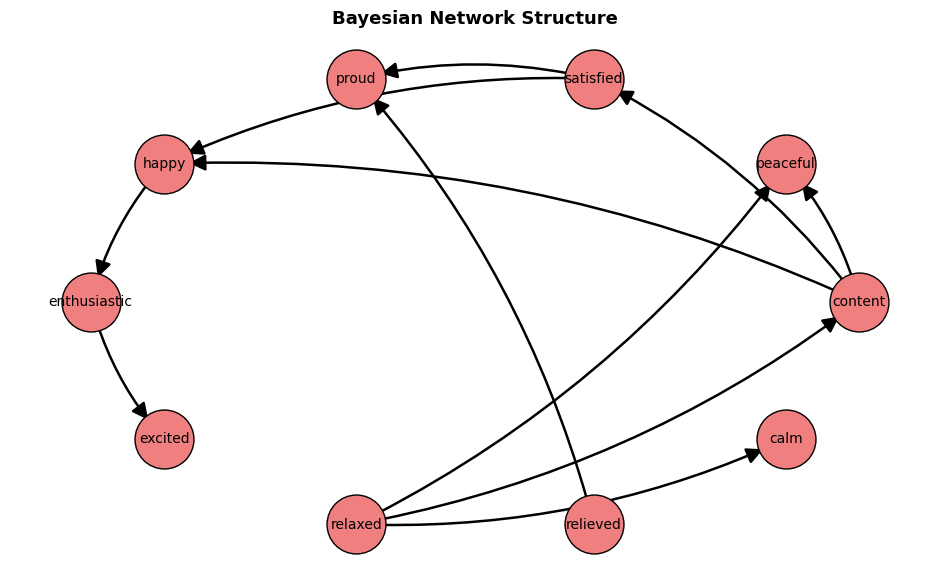

In [27]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_bn_sharp(dag, layout="kamada_kawai"):
    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(dag)
    elif layout == "spring":
        pos = nx.spring_layout(dag, seed=7, k=1.2, iterations=300)
    else:
        pos = nx.circular_layout(dag)

    plt.figure(figsize=(12,7))
    nx.draw_networkx_nodes(dag, pos, node_size=1800, node_color="#F08080", edgecolors="black")
    nx.draw_networkx_labels(dag, pos, font_size=10)

    # Bigger arrowheads + gentle curves to make direction obvious
    nx.draw_networkx_edges(
        dag, pos,
        arrows=True,           # ensure directed
        arrowstyle='-|>',      # triangular head
        arrowsize=24,          # bigger heads
        width=1.8,
        connectionstyle='arc3,rad=0.12',  # slight curve so edges don't overlap
        min_source_margin=18,  # keep heads off nodes
        min_target_margin=18
    )
    plt.axis("off")
    plt.title("Bayesian Network Structure", fontsize=13, fontweight="bold")
    plt.show()

visualize_bn_sharp(dag, layout="kamada_kawai")
